### Simulated Data
- Solve ODE

In [ ]:
#install.packages("deSolve")


The downloaded binary packages are in
	/var/folders/pb/8h8st6s556sg0h7lg6_k4_z80000gn/T//Rtmp0jgOX7/downloaded_packages


In [ ]:
library(deSolve)
library(ggplot2)
library(tidyr)

Warning message:
“package ‘deSolve’ was built under R version 4.5.2”


In [ ]:
two_comp_model <- function(t, state, parameters) {
  with(as.list(c(state, parameters)), {
    du_gut  <- -ka * u_gut
    du_cent <- ka * u_gut - (CL/Vcent + Q/Vcent) * u_cent + (Q/Vperi) * u_peri
    du_peri <- (Q/Vcent) * u_cent - (Q/Vperi) * u_peri
    return(list(c(du_gut, du_cent, du_peri)))
  })
}

n_ind <- 50  
Dose  <- 1200 

set.seed(123)
pop_params <- data.frame(
  id     = 1:n_ind,
  CL     = rlnorm(n_ind, log(10), 0.25),
  Q      = rlnorm(n_ind, log(15), 0.5),
  Vcent  = rlnorm(n_ind, log(35), 0.25),
  Vperi  = rlnorm(n_ind, log(105), 0.5),
  ka     = rlnorm(n_ind, log(2.5), 1),
  weight = rnorm(n_ind, 70, 10)
)

sigma_res <- abs(rnorm(1, 0, 1)) 

results_list <- lapply(1:n_ind, function(i) {
  p  <- unlist(pop_params[i, c("CL", "Q", "Vcent", "Vperi", "ka")])
  wt <- pop_params$weight[i]
  intensive_pts <- c(0.083, 0.167, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 6, 8)
  
  t_dose1 <- intensive_pts
  
  t_dose2 <- 12 + intensive_pts
  
  t_dose14 <- 156 + intensive_pts
  
  t_trough <- seq(0, 156, by = 12)
  
  t_washout <- 156 + c(12, 18, 24)
  
  all_obs_times <- sort(unique(c(t_dose1, t_dose2, t_dose14, t_trough, t_washout)))
  dose_times <- seq(0, 156, by = 12) # 0, 12, ... 156 (共14次)
  
  events_df <- data.frame(
    var    = "u_gut",       
    time   = dose_times,    
    value  = Dose,          
    method = "add"          
  )
  out <- as.data.frame(ode(y = c(u_gut=0, u_cent=0, u_peri=0), # 初始为0，药通过 events 加进去
                           times = all_obs_times, 
                           func = two_comp_model, 
                           parms = p,
                           events = list(data = events_df))) # <--- 这里传入多剂量事件
  dose_row <- data.frame(
    id = i, time = 0, addl = 13, ii = 12, amt = Dose, 
    cmt = 1, evid = 1, rate = 0, ss = 0, cObs = NA, weight = wt
  )
  obs_rows <- data.frame(
    id     = i,
    time   = out$time,
    addl   = 0,
    ii     = 0,
    amt    = 0,
    cmt    = 2,
    evid   = 0,
    rate   = 0,
    ss     = 0,
    cObs   = (out$u_cent / p["Vcent"]) + rnorm(nrow(out), 0, sigma_res),
    weight = wt
  )

  
  return(rbind(dose_row, obs_rows))
})

final_data <- do.call(rbind, results_list)
final_data <- final_data[order(final_data$id, final_data$time, -final_data$evid), ]
write.csv(final_data, "my_twoCpt_data.csv", row.names = FALSE, na = ".")

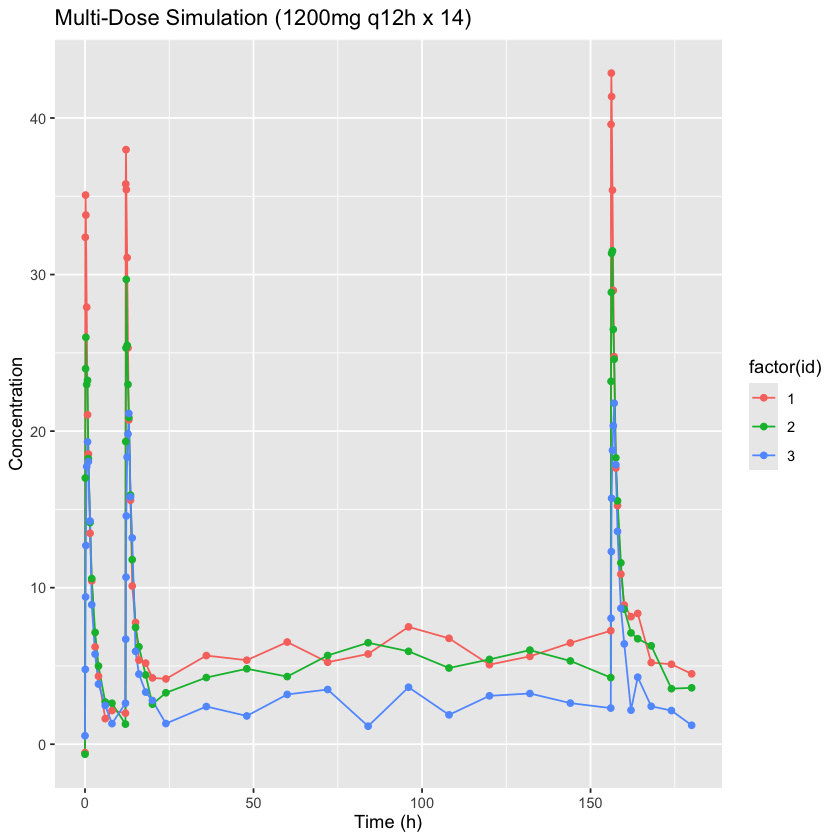

In [9]:

ggplot(subset(final_data, id <= 3 & evid == 0), aes(x = time, y = cObs, group = id, color = factor(id))) +
  geom_line() +
  geom_point() +
  labs(title = "Multi-Dose Simulation (1200mg q12h x 14)", x = "Time (h)", y = "Concentration")